In [4]:
#import
import numpy as np
import matplotlib.pyplot as plt

## 0. Conventions

$$[\hat x,\hat p] = i\hbar, \qquad \hat p = -i\hbar\frac{\partial}{\partial x}$$

$\hbar$, $m$, $\omega$ are kept **explicit** throughout this notebook.

> Many references instead use dimensionless quadratures
> $\hat X = \sqrt{m\omega/\hbar}\;\hat x$, $\hat P = \hat p/\sqrt{\hbar m\omega}$, with $[\hat X,\hat P]=i$.
> Watch out for this when comparing with QuTiP, Strawberry Fields, or Brask's notes.

## 1. From the Schrödinger equation to the harmonic oscillator

### 1.1 TDSE $\to$ TISE

$$i\hbar\,\frac{\partial}{\partial t}\Psi(x,t) = \hat H\,\Psi(x,t),
\qquad \hat H = -\frac{\hbar^{2}}{2m}\frac{\partial^{2}}{\partial x^{2}} + V(x)$$

Separating $\Psi(x,t) = \psi(x)f(t)$:

$$i\hbar\,\frac{1}{f}\frac{df}{dt} \;=\; \frac{1}{\psi}\hat H\psi \;=\; E$$

$$f(t) = e^{-iEt/\hbar},
\qquad\qquad \boxed{\;-\frac{\hbar^{2}}{2m}\frac{d^{2}\psi}{dx^{2}} + V(x)\,\psi = E\,\psi\;}$$

$$|\Psi(x,t)|^{2} = |\psi(x)|^{2} \quad\text{(stationary)},
\qquad \Psi(x,t) = \sum_{n} c_{n}\,\psi_{n}(x)\,e^{-iE_{n}t/\hbar}$$

### 1.2 Why the harmonic potential

Taylor-expand any smooth potential about a minimum $x_{\min}$:

$$V(x) = V(x_{\min})
+ \underbrace{V'(x_{\min})}_{=\,0}(x-x_{\min})
+ \frac{1}{2}V''(x_{\min})(x-x_{\min})^{2}
+ \mathcal{O}\big((x-x_{\min})^{3}\big)$$

Absorbing the constant and shifting $x_{\min}\to 0$:

$$\boxed{\;V(x) \simeq \frac{1}{2}m\omega^{2}x^{2},
\qquad \omega = \sqrt{\frac{V''(0)}{m}}\;}$$

So the harmonic oscillator is not a toy problem — it is the **universal local approximation near any
stable equilibrium**. A single mode of the electromagnetic field has exactly this Hamiltonian, which
is why quantum optics starts here.

$$-\frac{\hbar^{2}}{2m}\frac{d^{2}\psi}{dx^{2}} + \frac{1}{2}m\omega^{2}x^{2}\,\psi = E\,\psi$$

> Light from a lightbulb has no definite $|\psi\rangle$ at all. We come back to this in Section 5.

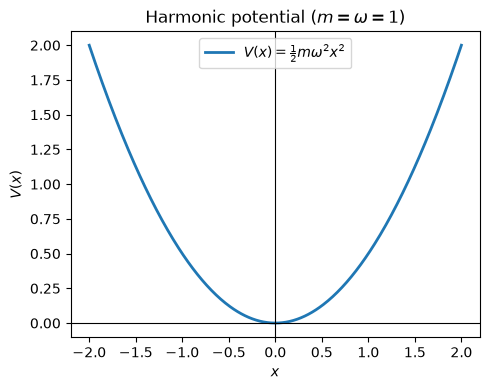

In [7]:
# harmonic potential
hbar, m, omega = 1.0, 1.0, 1.0

x = np.linspace(-2, 2, 400)
V = 0.5 * m * omega**2 * x**2

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(x, V, lw=2, label=r'$V(x)=\frac{1}{2}m\omega^{2}x^{2}$')
ax.axhline(0, color='k', lw=0.8)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$V(x)$')
ax.set_title(r'Harmonic potential ($m=\omega=1$)')
ax.legend()
fig.tight_layout()
plt.show()

## 2. Solving with ladder operators

### 2.1 Definition

$$\hat a = \frac{1}{\sqrt{2\hbar m\omega}}\Big(m\omega\,\hat x + i\,\hat p\Big),
\qquad
\hat a^{\dagger} = \frac{1}{\sqrt{2\hbar m\omega}}\Big(m\omega\,\hat x - i\,\hat p\Big)$$

$$\hat x = \sqrt{\frac{\hbar}{2m\omega}}\big(\hat a + \hat a^{\dagger}\big),
\qquad
\hat p = i\sqrt{\frac{\hbar m\omega}{2}}\big(\hat a^{\dagger} - \hat a\big)$$

### 2.2 Commutator

$$[\hat a,\hat a^{\dagger}]
= \frac{1}{2\hbar m\omega}\Big[\,m\omega\hat x + i\hat p,\;\; m\omega\hat x - i\hat p\,\Big]
= \frac{1}{2\hbar m\omega}\Big(-i\,m\omega[\hat x,\hat p] + i\,m\omega[\hat p,\hat x]\Big)$$

$$= \frac{1}{2\hbar m\omega}\Big(-i\,m\omega(i\hbar) + i\,m\omega(-i\hbar)\Big)
= \frac{2\hbar m\omega}{2\hbar m\omega} = 1$$

$$\boxed{\;[\hat a,\hat a^{\dagger}] = 1\;}$$

### 2.3 The Hamiltonian

$$\hat a^{\dagger}\hat a
= \frac{1}{2\hbar m\omega}\Big(m\omega\hat x - i\hat p\Big)\Big(m\omega\hat x + i\hat p\Big)
= \frac{1}{2\hbar m\omega}\Big(m^{2}\omega^{2}\hat x^{2} + \hat p^{\,2} + i\,m\omega[\hat x,\hat p]\Big)$$

$$= \frac{1}{\hbar\omega}\left(\frac{\hat p^{\,2}}{2m} + \frac{1}{2}m\omega^{2}\hat x^{2}\right) - \frac{1}{2}
= \frac{\hat H}{\hbar\omega} - \frac{1}{2}$$

$$\boxed{\;\hat H = \hbar\omega\left(\hat a^{\dagger}\hat a + \frac{1}{2}\right)
= \hbar\omega\left(\hat n + \frac{1}{2}\right), \qquad \hat n = \hat a^{\dagger}\hat a\;}$$

### 2.4 Spectrum

$$\hat n|n\rangle = n|n\rangle,
\qquad \hat a|n\rangle = \sqrt{n}\,|n-1\rangle,
\qquad \hat a^{\dagger}|n\rangle = \sqrt{n+1}\,|n+1\rangle$$

$$E_{n} = \hbar\omega\left(n+\frac{1}{2}\right), \qquad n = 0,1,2,\dots$$

$$E_{0} = \frac{1}{2}\hbar\omega \neq 0 \qquad \text{(zero-point energy)}$$

### 2.5 Ground state — a first-order ODE

$$\hat a|0\rangle = 0
\qquad\Longrightarrow\qquad
\left(m\omega x + \hbar\frac{d}{dx}\right)\psi_{0}(x) = 0$$

$$\frac{d\psi_{0}}{\psi_{0}} = -\frac{m\omega}{\hbar}\,x\,dx
\qquad\Longrightarrow\qquad
\ln\psi_{0} = -\frac{m\omega}{2\hbar}x^{2} + \text{const}$$

$$\boxed{\;\psi_{0}(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}
\exp\left(-\frac{m\omega x^{2}}{2\hbar}\right)\;}$$

A Gaussian, with no second-order series solution anywhere in sight.

### 2.6 Excited states

$$|n\rangle = \frac{\left(\hat a^{\dagger}\right)^{n}}{\sqrt{n!}}\,|0\rangle$$

$$\psi_{n}(x) = \frac{1}{\sqrt{2^{n}n!}}\left(\frac{m\omega}{\pi\hbar}\right)^{1/4}
H_{n}\!\left(\sqrt{\frac{m\omega}{\hbar}}\;x\right)
\exp\left(-\frac{m\omega x^{2}}{2\hbar}\right)$$

> Griffiths writes $\hat a_{+} = \hat a^{\dagger}$ and $\hat a_{-} = \hat a$; the dagger genuinely
> swaps them, $\hat a_{\pm}^{\dagger} = \hat a_{\mp}$.

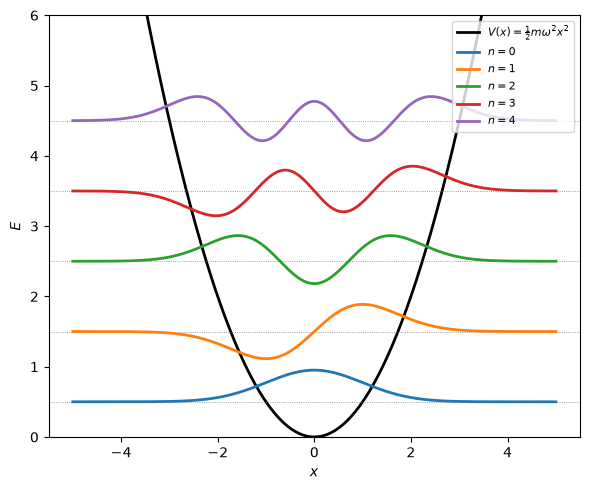

In [13]:
# SHO in potential
from math import factorial

N = 5
scale = 0.6                       # 파동함수 시각적 크기

x = np.linspace(-5, 5, 400)       # n=4 turning point가 x=3이라 -2~2로는 잘림
V = 0.5 * m * omega**2 * x**2

def H_n(n, x):
    return np.polynomial.hermite.hermval(x, [0]*n + [1])

psi = []
for n in range(N):
    C = (1/np.sqrt(2**n * factorial(n))) * (m*omega/(np.pi*hbar))**0.25
    psi.append(C * H_n(n, np.sqrt(m*omega/hbar)*x) * np.exp(-m*omega*x**2/(2*hbar)))

E = [hbar*omega*(n + 0.5) for n in range(N)]

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(x, V, 'k', lw=2, label=r'$V(x)=\frac{1}{2}m\omega^{2}x^{2}$')
for n in range(N):
    ax.axhline(E[n], color='gray', lw=0.6, ls=':')
    ax.plot(x, scale*psi[n] + E[n], lw=2, label=rf'$n={n}$')

ax.set_ylim(0, E[-1] + 1.5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$E$')
ax.legend(loc='upper right', fontsize=8)
fig.tight_layout()
plt.show()

### 2.7 What a Fock state cannot do

$$\langle n|\hat x|n\rangle
= \sqrt{\frac{\hbar}{2m\omega}}\Big(\sqrt{n}\,\langle n|n-1\rangle + \sqrt{n+1}\,\langle n|n+1\rangle\Big) = 0$$

$$\langle n|\hat p|n\rangle = 0 \qquad \text{for all } n$$

Definite energy, **no phase**. But laser light oscillates. So we need different observables.

## 3. Hermiticity: what is actually measurable

$$\hat a^{\dagger} \neq \hat a \qquad\Longrightarrow\qquad \hat a \text{ is not an observable}$$

$$\hat n^{\dagger} = \big(\hat a^{\dagger}\hat a\big)^{\dagger} = \hat a^{\dagger}\hat a = \hat n
\quad\checkmark$$

$$\hat x^{\dagger} = \sqrt{\frac{\hbar}{2m\omega}}\big(\hat a^{\dagger} + \hat a\big) = \hat x
\quad\checkmark$$

$$\hat p^{\dagger}
= \left[i\sqrt{\frac{\hbar m\omega}{2}}\big(\hat a^{\dagger}-\hat a\big)\right]^{\dagger}
= -i\sqrt{\frac{\hbar m\omega}{2}}\big(\hat a - \hat a^{\dagger}\big) = \hat p
\quad\checkmark$$

### 3.1 Robertson relation

Valid only for **Hermitian** pairs:

$$\Delta A\,\Delta B \;\ge\; \frac{1}{2}\Big|\big\langle[\hat A,\hat B]\big\rangle\Big|
\qquad\Longrightarrow\qquad
\Delta x\,\Delta p \ge \frac{\hbar}{2}$$

To talk about uncertainty at all we must use $\hat x,\hat p$ — not $\hat a$.
**These two continuous observables are what "continuous variable" refers to.**

### 3.2 Vacuum variances

$$\hat x^{2} = \frac{\hbar}{2m\omega}
\big(\hat a^{2} + \hat a\hat a^{\dagger} + \hat a^{\dagger}\hat a + \hat a^{\dagger 2}\big)$$

$$\langle 0|\hat x^{2}|0\rangle
= \frac{\hbar}{2m\omega}\langle 0|\hat a\hat a^{\dagger}|0\rangle
= \frac{\hbar}{2m\omega}\langle 0|\big(1+\hat a^{\dagger}\hat a\big)|0\rangle
= \frac{\hbar}{2m\omega}$$

$$\langle 0|\hat p^{2}|0\rangle = \frac{\hbar m\omega}{2},
\qquad \langle 0|\hat x|0\rangle = \langle 0|\hat p|0\rangle = 0$$

$$\Delta x\,\Delta p
= \sqrt{\frac{\hbar}{2m\omega}}\cdot\sqrt{\frac{\hbar m\omega}{2}}
= \frac{\hbar}{2}$$

The vacuum **saturates** the uncertainty relation.

| operator | Hermitian | observable | meaning |
|---|:---:|:---:|---|
| $\hat a,\;\hat a^{\dagger}$ | ✗ | ✗ | annihilation / creation (bookkeeping) |
| $\hat n = \hat a^{\dagger}\hat a$ | ✓ | ✓ | photon number |
| $\hat x,\;\hat p$ | ✓ | ✓ | position / momentum — the CV observables |

In [ ]:
# [CODE] truncated matrices: check x = x^dagger, and [x,p] ~ i*hbar*I (note the truncation error in the last diagonal entry)

## 4. Bra-ket notation and representations

### 4.1 Order matters

$$\langle\phi|\psi\rangle \in \mathbb{C} \quad\text{(scalar)},
\qquad\qquad
|\psi\rangle\langle\phi| \quad\text{(operator)}$$

### 4.2 A wavefunction is a set of components

$$\psi(x) = \langle x|\psi\rangle,
\qquad c_{n} = \langle n|\psi\rangle,
\qquad |\psi\rangle = \sum_{n=0}^{\infty} c_{n}|n\rangle$$

### 4.3 Completeness

$$\sum_{n=0}^{\infty}|n\rangle\langle n| = \hat{\mathbb{1}},
\qquad \int_{-\infty}^{\infty}\!dx\;|x\rangle\langle x| = \hat{\mathbb{1}}$$

$$\langle n|m\rangle = \delta_{nm}, \qquad \langle x|x'\rangle = \delta(x-x')$$

### 4.4 Inserting the identity

$$\psi(x) = \langle x|\hat{\mathbb{1}}|\psi\rangle
= \sum_{n}\langle x|n\rangle\langle n|\psi\rangle
= \sum_{n} c_{n}\,\psi_{n}(x)$$

> The same move reappears in Section 5.4 to convert $\rho_{nm}\to\rho(x,x')$.

### 4.5 Operators

$$A_{nm} = \langle n|\hat A|m\rangle,
\qquad \hat A = \sum_{n,m}A_{nm}\,|n\rangle\langle m|,
\qquad \langle\hat A\rangle = \langle\psi|\hat A|\psi\rangle$$

### 4.6 Momentum representation

$$\langle x|p\rangle = \frac{1}{\sqrt{2\pi\hbar}}\,e^{ipx/\hbar}$$

$$\tilde\psi(p) = \langle p|\psi\rangle
= \frac{1}{\sqrt{2\pi\hbar}}\int_{-\infty}^{\infty}\!dx\;\psi(x)\,e^{-ipx/\hbar}$$

> Position and momentum are Fourier conjugates. This exact transform returns in Section 6.

In [ ]:
# [CODE] one state, two pictures: bar chart of c_n vs psi(x) reconstructed from sum_n c_n psi_n(x)

## 5. The density matrix

### 5.1 When a ket is not enough

1. **Classical ignorance.** A thermal source emits some $|\psi_{i}\rangle$; we only know the probabilities $p_{i}$.
2. **Subsystems.** Trace out half of an entangled pair and the rest has no state vector of its own.

### 5.2 Definition

$$\rho = |\psi\rangle\langle\psi| \qquad \text{(pure)}$$

$$\rho = \sum_{i} p_{i}\,|\psi_{i}\rangle\langle\psi_{i}|,
\qquad p_{i}\ge 0,\quad \sum_{i}p_{i} = 1 \qquad \text{(mixed)}$$

$$\langle\hat A\rangle = \mathrm{Tr}\big(\rho\,\hat A\big)$$

### 5.3 Superposition is not mixture

$$|\psi\rangle = \frac{1}{\sqrt{2}}\big(|0\rangle+|1\rangle\big)
\qquad\Longrightarrow\qquad
\rho_{\text{sup}} = \frac{1}{2}\begin{pmatrix} 1 & 1 \\ 1 & 1 \end{pmatrix}$$

$$\rho_{\text{mix}} = \frac{1}{2}|0\rangle\langle 0| + \frac{1}{2}|1\rangle\langle 1|
= \frac{1}{2}\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$$

$$\mathrm{diag}\big(\rho_{\text{sup}}\big) = \mathrm{diag}\big(\rho_{\text{mix}}\big)
\qquad\Longrightarrow\qquad \text{photon-number statistics cannot tell them apart}$$

The whole difference sits in the **off-diagonal elements** $\rho_{01},\rho_{10}$ — the *coherences*.

### 5.4 Two representations

$$\rho_{nm} = \langle n|\rho|m\rangle \qquad \text{(Fock basis, formally } \infty\times\infty\text{)}$$

$$\rho(x,x') = \langle x|\rho|x'\rangle,
\qquad \text{pure state: } \rho(x,x') = \psi(x)\,\psi^{*}(x')$$

Inserting the identity twice connects them:

$$\rho(x,x') = \langle x|\hat{\mathbb{1}}\,\rho\,\hat{\mathbb{1}}|x'\rangle
= \sum_{n,m}\rho_{nm}\;\psi_{n}(x)\,\psi_{m}^{*}(x')$$

> **Cutoff.** Numerically $\rho_{nm}$ must be truncated at $n,m \le N_{\text{cut}}$. Fock states have
> finitely many components, but coherent and squeezed states have support on the whole Hilbert space —
> too small a cutoff visibly corrupts everything computed from them.

### 5.5 Where we are going

$$\rho(x,x) = |\psi(x)|^{2} \qquad \text{(the diagonal)}$$

So what is stored in the *off*-diagonal direction, $x \neq x'$?

Tr rho = 0.9999999999641052


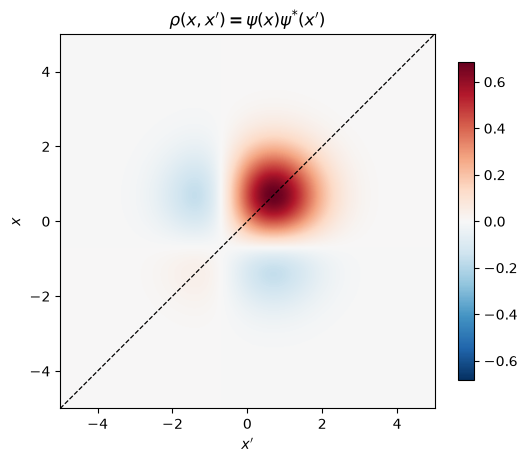

In [ ]:
# density matrix
x = np.linspace(-5, 5, 400)          # psi는 |x|>4에서 사실상 0
dx = x[1] - x[0]

def psi_n(n, x):
    C = (1/np.sqrt(2**n * factorial(n))) * (m*omega/(np.pi*hbar))**0.25
    return C * H_n(n, np.sqrt(m*omega/hbar)*x) * np.exp(-m*omega*x**2/(2*hbar))

# superposition
psi_sup = (psi_n(0, x) + psi_n(1, x)) / np.sqrt(2)

rho = np.outer(psi_sup, psi_sup.conj())      # rho(x,x') = psi(x) psi*(x')

print("Tr rho =", np.sum(np.diag(rho))*dx)   # 1이 나와야 함

vmax = np.abs(rho).max()
fig, ax = plt.subplots(figsize=(5.5, 4.6))
im = ax.imshow(rho.real, extent=[x[0], x[-1], x[0], x[-1]],
               origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.plot(x, x, 'k--', lw=0.9)                 # 대각선 x = x'
ax.set_xlabel(r"$x'$")
ax.set_ylabel(r"$x$")
ax.set_title(r"$\rho(x,x')=\psi(x)\psi^{*}(x')$")
fig.colorbar(im, ax=ax, shrink=0.85)
fig.tight_layout()
plt.show()

## 6. The Wigner function

### 6.1 Centre and relative coordinates

$$\bar x = \frac{x+x'}{2} \quad\text{(centre)},
\qquad y = x - x' \quad\text{(relative)}$$

$$x = \bar x + \frac{y}{2}, \qquad x' = \bar x - \frac{y}{2}$$

$$\rho(x,x') \;\longrightarrow\; \rho\!\left(\bar x + \frac{y}{2},\;\bar x - \frac{y}{2}\right)$$

* $y = 0$: the position probability density
* $y \neq 0$: this is where the momentum information lives

### 6.2 Fourier transform in the relative coordinate

Position and momentum are Fourier conjugates (Section 4.6), and the variable conjugate to the
relative coordinate $y$ is again $p$:

$$\boxed{\;W(x,p) = \frac{1}{2\pi\hbar}\int_{-\infty}^{\infty}\!dy\;
\rho\!\left(x+\frac{y}{2},\;x-\frac{y}{2}\right)e^{-ipy/\hbar}\;}$$

For a pure state:

$$W(x,p) = \frac{1}{2\pi\hbar}\int_{-\infty}^{\infty}\!dy\;
\psi\!\left(x+\frac{y}{2}\right)\psi^{*}\!\left(x-\frac{y}{2}\right)e^{-ipy/\hbar}$$

A function of $x$ **and** $p$ at the same time — a distribution over phase space.

### 6.3 Example: the vacuum

$$\psi_{0}(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4}
\exp\left(-\frac{m\omega x^{2}}{2\hbar}\right)$$

$$\psi_{0}\!\left(x+\frac{y}{2}\right)\psi_{0}^{*}\!\left(x-\frac{y}{2}\right)
= \left(\frac{m\omega}{\pi\hbar}\right)^{1/2}
\exp\left[-\frac{m\omega}{2\hbar}\left(\Big(x+\tfrac{y}{2}\Big)^{2}+\Big(x-\tfrac{y}{2}\Big)^{2}\right)\right]$$

$$= \left(\frac{m\omega}{\pi\hbar}\right)^{1/2}
\exp\left(-\frac{m\omega x^{2}}{\hbar}\right)
\exp\left(-\frac{m\omega y^{2}}{4\hbar}\right)$$

Using $\displaystyle\int_{-\infty}^{\infty} e^{-\alpha y^{2}}e^{-i\beta y}\,dy
= \sqrt{\frac{\pi}{\alpha}}\;e^{-\beta^{2}/4\alpha}$
with $\alpha = \dfrac{m\omega}{4\hbar}$, $\beta = \dfrac{p}{\hbar}$:

$$\int_{-\infty}^{\infty}\!dy\; e^{-m\omega y^{2}/4\hbar}\,e^{-ipy/\hbar}
= \sqrt{\frac{4\pi\hbar}{m\omega}}\;\exp\left(-\frac{p^{2}}{\hbar m\omega}\right)$$

Collecting the prefactors,

$$\frac{1}{2\pi\hbar}\left(\frac{m\omega}{\pi\hbar}\right)^{1/2}
\left(\frac{4\pi\hbar}{m\omega}\right)^{1/2} = \frac{1}{\pi\hbar}$$

$$\boxed{\;W_{0}(x,p) = \frac{1}{\pi\hbar}
\exp\left(-\frac{m\omega x^{2}}{\hbar} - \frac{p^{2}}{\hbar m\omega}\right)\;}$$

A Gaussian centred on the origin of phase space.

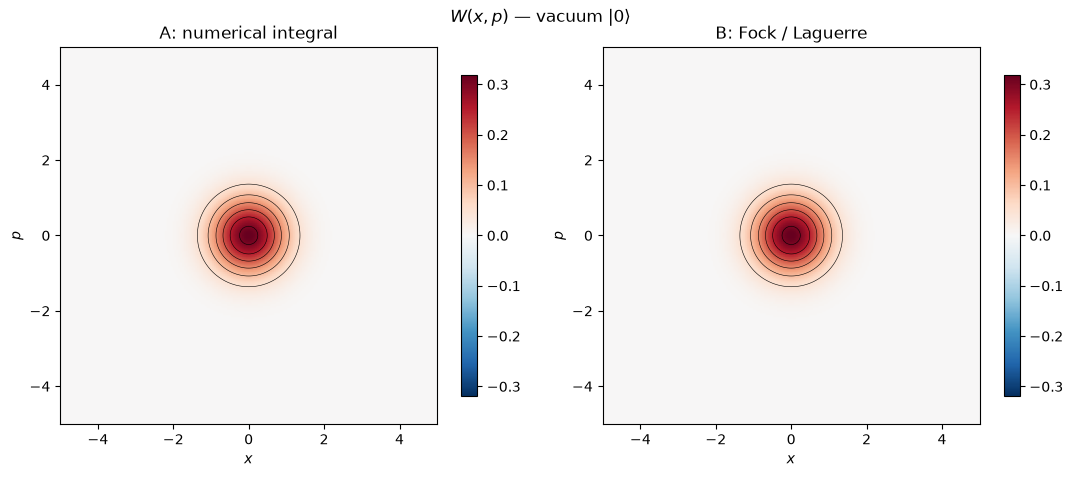

max |A - B| = 7.716050021144838e-15


In [ ]:
# Wigner function
x = np.linspace(-5, 5, 201)
p = np.linspace(-5, 5, 201)
y = np.linspace(-12, 12, 801)      
dy = y[1] - y[0]

# --- 방법 A: 정의대로 수치적분 ---
def wigner_numeric(n, x, p, y):
    X, Y = np.meshgrid(x, y, indexing='ij')            # (Nx, Ny)
    K = psi_n(n, X + Y/2) * np.conj(psi_n(n, X - Y/2)) # rho(x+y/2, x-y/2)
    F = np.exp(-1j * np.outer(p, y) / hbar)            # (Np, Ny)
    return (K @ F.T).real * dy / (2*np.pi*hbar)        # (Nx, Np)

# --- 방법 B: Fock/Laguerre 닫힌 꼴 ---
def wigner_fock(n, x, p):
    X, P = np.meshgrid(x, p, indexing='ij')
    r2 = m*omega*X**2/hbar + P**2/(hbar*m*omega)
    L = np.polynomial.laguerre.lagval(2*r2, [0]*n + [1])
    return (-1)**n / (np.pi*hbar) * np.exp(-r2) * L

W_num  = wigner_numeric(0, x, p, y)
W_fock = wigner_fock(0, x, p)

X, P = np.meshgrid(x, p, indexing='ij')
vm = np.abs(W_num).max()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, W, t in zip(axes, [W_num, W_fock],
                    ['A: numerical integral', 'B: Fock / Laguerre']):
    im = ax.imshow(W.T, extent=[x[0], x[-1], p[0], p[-1]], origin='lower',
                   cmap='RdBu_r', vmin=-vm, vmax=vm)
    ax.contour(X, P, W, levels=6, colors='k', linewidths=0.4)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$p$')
    ax.set_title(t)
    fig.colorbar(im, ax=ax, shrink=0.85)

fig.suptitle(r'$W(x,p)$ — vacuum $|0\rangle$')
fig.tight_layout()
plt.show()

print("max |A - B| =", np.abs(W_num - W_fock).max())

## 7. Phase space: the classical circle and the quantum blob

### 7.1 Classically, a point on a circle

$$H(x,p) = \frac{p^{2}}{2m} + \frac{1}{2}m\omega^{2}x^{2}$$

$$\dot x = \frac{\partial H}{\partial p} = \frac{p}{m},
\qquad \dot p = -\frac{\partial H}{\partial x} = -m\omega^{2}x$$

$$x(t) = A\cos(\omega t+\phi), \qquad p(t) = -m\omega A\sin(\omega t+\phi)$$

The trajectory is the energy contour

$$\frac{p^{2}}{2m} + \frac{1}{2}m\omega^{2}x^{2} = E,$$

an ellipse. Rescaling

$$\xi = \sqrt{m\omega}\;x, \qquad \eta = \frac{p}{\sqrt{m\omega}}
\qquad\Longrightarrow\qquad H = \frac{\omega}{2}\big(\xi^{2}+\eta^{2}\big)$$

turns it into a **circle of radius $\sqrt{2E/\omega}$**, traced at constant angular velocity $\omega$.

$$\text{classical state} = \text{a single point } (x,p) \text{ on that circle}, \qquad \text{area} = 0$$

In [ ]:
# [CODE] classical trajectories: circles/ellipses for a few energies, with the state as a moving point

### 7.2 Quantum mechanically, a point is forbidden

$$\Delta x\,\Delta p \ge \frac{\hbar}{2}
\qquad\Longrightarrow\qquad
\delta(x-x_{0})\,\delta(p-p_{0}) \;\text{ is not allowed}$$

A point has zero area; the uncertainty relation demands a minimum. So the state cannot sit *on* the
circle — it must be spread out into a **blob** of area of order $\hbar$.

Crucially, this blob is **not ignorance**. In classical statistical mechanics a distribution
$f(x,p)$ describes a real point we simply failed to locate, and nothing forbids
$f \to \delta$-function. Here there is no hidden point. **The blob is the state**, in the same way
that $|+\rangle = \tfrac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ is not secretly $|0\rangle$ or $|1\rangle$.

| | classical $f(x,p)$ | quantum $W(x,p)$ |
|---|---|---|
| meaning of the spread | our ignorance | the state itself |
| hidden true value | yes, $(x_{0},p_{0})$ | none |
| sharpest possible | $\delta$-function | $\Delta x\,\Delta p \ge \hbar/2$ |

### 7.3 The vacuum blob

$$W_{0}(x,p) = \frac{1}{\pi\hbar}
\exp\left(-\frac{m\omega x^{2}}{\hbar} - \frac{p^{2}}{\hbar m\omega}\right)$$

$$\Delta x = \sqrt{\frac{\hbar}{2m\omega}},
\qquad \Delta p = \sqrt{\frac{\hbar m\omega}{2}},
\qquad \Delta x\,\Delta p = \frac{\hbar}{2}$$

In the rescaled coordinates $(\xi,\eta)$ of Section 7.1 the exponent becomes
$-\big(\xi^{2}+\eta^{2}\big)/\hbar$: the vacuum is an **isotropic** blob, a round patch of fuzz
sitting at the origin. Its contours are circles, but the state is the whole patch, not any one of them.

### 7.4 Squeezing: same area, different shape

$$\hat S(r) = \exp\left[\frac{r}{2}\Big(\hat a^{2} - \hat a^{\dagger 2}\Big)\right],
\qquad
\hat S^{\dagger}(r)\,\hat a\,\hat S(r) = \hat a\cosh r - \hat a^{\dagger}\sinh r$$

$$\Delta x^{2} = \frac{\hbar}{2m\omega}\,e^{-2r},
\qquad
\Delta p^{2} = \frac{\hbar m\omega}{2}\,e^{+2r},
\qquad
\Delta x\,\Delta p = \frac{\hbar}{2}$$

$$\boxed{\;W_{r}(x,p) = \frac{1}{\pi\hbar}
\exp\left(-\frac{m\omega x^{2}}{\hbar}e^{2r} - \frac{p^{2}}{\hbar m\omega}e^{-2r}\right)\;}$$

The uncertainty product is unchanged, so the blob keeps the same area — it is only **deformed**:
narrower in $x$ by $e^{-r}$, wider in $p$ by $e^{+r}$. The noise has been pushed from one quadrature
into the other, which is exactly what makes squeezed light useful for precision measurement.

In [ ]:
# [CODE] vacuum blob vs squeezed blob in phase space (contours), with the classical energy circle for comparison

### 7.5 Gaussian states in general

Write $\mathbf r = (x,p)^{T}$ and $\bar{\mathbf r} = \big(\langle\hat x\rangle,\langle\hat p\rangle\big)^{T}$.
The covariance matrix is

$$\sigma_{jk} = \frac{1}{2}\Big\langle \big\{\Delta\hat r_{j},\,\Delta\hat r_{k}\big\}\Big\rangle,
\qquad \Delta\hat r_{j} = \hat r_{j} - \langle\hat r_{j}\rangle$$

and every Gaussian state is fully described by these two objects alone:

$$W(\mathbf r) = \frac{1}{2\pi\sqrt{\det\sigma}}
\exp\left[-\frac{1}{2}\big(\mathbf r - \bar{\mathbf r}\big)^{T}\sigma^{-1}\big(\mathbf r - \bar{\mathbf r}\big)\right]$$

$$\text{vacuum: } \sigma = \begin{pmatrix} \dfrac{\hbar}{2m\omega} & 0 \\[6pt] 0 & \dfrac{\hbar m\omega}{2}\end{pmatrix},
\qquad
\text{squeezed: } \sigma = \begin{pmatrix} \dfrac{\hbar}{2m\omega}e^{-2r} & 0 \\[6pt] 0 & \dfrac{\hbar m\omega}{2}e^{2r}\end{pmatrix}$$

$$\det\sigma \ge \frac{\hbar^{2}}{4} \qquad \text{(uncertainty relation, in matrix form)}$$

The mean vector moves the blob; the covariance matrix sets its shape. Nothing else is needed —
which is also why Gaussian states can be simulated efficiently on a classical computer, and why the
interesting quantum behaviour begins where $W$ goes negative.